# Project 3: Time Series Analysis and Forecasting

## Project Objective

The objective of this project is to analyze time-series data and apply different forecasting techniques to understand patterns, trends, seasonality, and future values.

In this project, we will work with multiple time-series datasets and explore:

- Moving Average
- Exponential Smoothing
- Seasonal Decomposition
- Stationarity and Dickey-Fuller (ADF) Test
- Auto-Regressive (AR) Model
- Moving Average (MA) Model
- ARMA Model
- Differencing
- ARIMA Model
- Forecasting
- Model Evaluation using RMSE and MAPE
- Residual Analysis
- Actual vs Forecast comparison

The project will demonstrate how time-series forecasting can be used for applications such as demand forecasting, sales forecasting, and other business planning activities.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully!")

All required libraries imported successfully!


## 📂 Dataset Loading & Understanding

The project uses three time series datasets to demonstrate different forecasting and time series analysis techniques.

Before applying forecasting models, the datasets were loaded and examined to understand their structure, variables, data types, missing values, and statistical characteristics.

### 📁 Datasets Used

| Dataset | Description | Main Variable |
|---|---|---|
| ✈️ Vimana | Aircraft demand over sequential time periods | `demand` |
| 🛍️ WSB | Monthly sales and promotional information | `Sale Quantity` |
| 🏪 Store | Daily store demand observations | `demand` |

### 🔎 Data Understanding Approach

The following checks were performed:

- Dataset dimensions and number of observations
- Column names and data types
- Missing-value checks
- Statistical summaries
- Time ordering and date/time structure
- Identification of the main target variable for forecasting

These checks help ensure that the datasets are suitable for subsequent time series analysis and forecasting.

In [2]:
# Load the datasets

vimana = pd.read_csv("vimana.csv")
wsb = pd.read_csv("wsb.csv")
store = pd.read_excel("store.xls")

print("Vimana Dataset Shape:", vimana.shape)
print("WSB Dataset Shape:", wsb.shape)
print("Store Dataset Shape:", store.shape)

Vimana Dataset Shape: (37, 2)
WSB Dataset Shape: (48, 4)
Store Dataset Shape: (115, 2)


In [3]:
# Check the first 5 rows of each dataset

print("===== VIMANA DATASET =====")
display(vimana.head())

print("\n===== WSB DATASET =====")
display(wsb.head())

print("\n===== STORE DATASET =====")
display(store.head())

===== VIMANA DATASET =====


,Month,demand
0,1,457
1,2,439
2,3,404
3,4,392
4,5,403



===== WSB DATASET =====


,Month,Sale Quantity,Promotion Expenses,Competition Promotion
0,1,3002666,105,1
1,2,4401553,145,0
2,3,3205279,118,1
3,4,4245349,130,0
4,5,3001940,98,1



===== STORE DATASET =====


,Date,demand
0,2014-10-01,15
1,2014-10-02,7
2,2014-10-03,8
3,2014-10-04,10
4,2014-10-05,13


In [4]:
# Dataset information

datasets = {
    "Vimana": vimana,
    "WSB": wsb,
    "Store": store
}

for name, df in datasets.items():
    print("=" * 50)
    print(name, "DATASET")
    print("=" * 50)
    
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())

Vimana DATASET

Columns:
['Month', 'demand']

Data Types:
Month     int64
demand    int64
dtype: object

Missing Values:
Month     0
demand    0
dtype: int64
WSB DATASET

Columns:
['Month', 'Sale Quantity', 'Promotion Expenses', 'Competition Promotion']

Data Types:
Month                    int64
Sale Quantity            int64
Promotion Expenses       int64
Competition Promotion    int64
dtype: object

Missing Values:
Month                    0
Sale Quantity            0
Promotion Expenses       0
Competition Promotion    0
dtype: int64
Store DATASET

Columns:
['Date', 'demand']

Data Types:
Date      datetime64[us]
demand             int64
dtype: object

Missing Values:
Date      0
demand    0
dtype: int64


In [5]:
# Statistical summary of all datasets

print("===== VIMANA DATASET =====")
display(vimana.describe())

print("===== WSB DATASET =====")
display(wsb.describe())

print("===== STORE DATASET =====")
display(store.describe())

===== VIMANA DATASET =====


,Month,demand
count,37.000000,37.000000
mean,19.000000,538.378378
std,10.824355,128.567179
min,1.000000,358.000000
25%,10.000000,439.000000
50%,19.000000,516.000000
75%,28.000000,629.000000
max,37.000000,864.000000


===== WSB DATASET =====


,Month,Sale Quantity,Promotion Expenses,Competition Promotion
count,48.00,4.800000e+01,48.000000,48.000000
mean,24.50,3.825340e+06,137.229167,0.395833
std,14.00,6.233543e+05,20.911403,0.494204
min,1.00,2.798343e+06,98.000000,0.000000
25%,12.75,3.338460e+06,120.750000,0.000000
50%,24.50,3.724724e+06,135.500000,0.000000
75%,36.25,4.322192e+06,157.000000,1.000000
max,48.00,5.431651e+06,170.000000,1.000000


===== STORE DATASET =====


,Date,demand
count,115,115.000000
mean,2014-11-27 00:00:00,13.591304
min,2014-10-01 00:00:00,5.000000
25%,2014-10-29 12:00:00,10.000000
50%,2014-11-27 00:00:00,13.000000
75%,2014-12-25 12:00:00,20.000000
max,2015-01-23 00:00:00,22.000000
std,NaN,5.263072


## 📊 Exploratory Time Series Analysis

Exploratory analysis was performed to understand how demand and sales change over time.

Time series visualization helps identify:

- 📈 Overall trends
- 🔄 Repeated patterns
- 📉 Sudden increases or decreases
- 📊 Variability in demand
- 🗓️ Possible seasonal behavior

The three datasets were visualized separately because they represent different time-dependent business scenarios.

---

### ✈️ Vimana Aircraft Demand

The Vimana dataset contains sequential observations of aircraft demand.

The demand series is plotted over time to understand its overall movement and identify periods of higher or lower demand.

---

### 🛍️ WSB Sales Quantity

The WSB dataset contains monthly sales quantities.

The time series plot helps examine changes in sales volume and identify potential fluctuations or recurring patterns.

---

### 🏪 Store Demand

The Store dataset contains daily demand observations with actual calendar dates.

The time series visualization helps identify changes in store demand over the observation period and provides a foundation for subsequent forecasting analysis.

In [6]:
# Convert time columns into datetime format

vimana["Month"] = pd.to_datetime(vimana["Month"])
wsb["Month"] = pd.to_datetime(wsb["Month"])
store["Date"] = pd.to_datetime(store["Date"])

print("Vimana Month type:", vimana["Month"].dtype)
print("WSB Month type:", wsb["Month"].dtype)
print("Store Date type:", store["Date"].dtype)

Vimana Month type: datetime64[ns]
WSB Month type: datetime64[ns]
Store Date type: datetime64[us]


In [7]:
# Sort all datasets by their time columns

vimana = vimana.sort_values("Month").reset_index(drop=True)
wsb = wsb.sort_values("Month").reset_index(drop=True)
store = store.sort_values("Date").reset_index(drop=True)

print("Vimana date range:")
print(vimana["Month"].min(), "to", vimana["Month"].max())

print("\nWSB date range:")
print(wsb["Month"].min(), "to", wsb["Month"].max())

print("\nStore date range:")
print(store["Date"].min(), "to", store["Date"].max())

Vimana date range:
1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000000037

WSB date range:
1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000000048

Store date range:
2014-10-01 00:00:00 to 2015-01-23 00:00:00


In [8]:
print("Vimana Month values:")
print(vimana["Month"].head(10))

print("\nWSB Month values:")
print(wsb["Month"].head(10))

Vimana Month values:
0   1970-01-01 00:00:00.000000001
1   1970-01-01 00:00:00.000000002
2   1970-01-01 00:00:00.000000003
3   1970-01-01 00:00:00.000000004
4   1970-01-01 00:00:00.000000005
5   1970-01-01 00:00:00.000000006
6   1970-01-01 00:00:00.000000007
7   1970-01-01 00:00:00.000000008
8   1970-01-01 00:00:00.000000009
9   1970-01-01 00:00:00.000000010
Name: Month, dtype: datetime64[ns]

WSB Month values:
0   1970-01-01 00:00:00.000000001
1   1970-01-01 00:00:00.000000002
2   1970-01-01 00:00:00.000000003
3   1970-01-01 00:00:00.000000004
4   1970-01-01 00:00:00.000000005
5   1970-01-01 00:00:00.000000006
6   1970-01-01 00:00:00.000000007
7   1970-01-01 00:00:00.000000008
8   1970-01-01 00:00:00.000000009
9   1970-01-01 00:00:00.000000010
Name: Month, dtype: datetime64[ns]


In [9]:
# Vimana and WSB use month numbers, not calendar dates.
# Convert them to a simple sequential time index.

vimana["Time"] = range(1, len(vimana) + 1)
wsb["Time"] = range(1, len(wsb) + 1)

# Store already has actual dates
store["Date"] = pd.to_datetime(store["Date"])

print("Vimana:")
display(vimana.head())

print("WSB:")
display(wsb.head())

print("Store:")
display(store.head())

Vimana:


,Month,demand,Time
0,1970-01-01 00:00:00.000000001,457,1
1,1970-01-01 00:00:00.000000002,439,2
2,1970-01-01 00:00:00.000000003,404,3
3,1970-01-01 00:00:00.000000004,392,4
4,1970-01-01 00:00:00.000000005,403,5


WSB:


,Month,Sale Quantity,Promotion Expenses,Competition Promotion,Time
0,1970-01-01 00:00:00.000000001,3002666,105,1,1
1,1970-01-01 00:00:00.000000002,4401553,145,0,2
2,1970-01-01 00:00:00.000000003,3205279,118,1,3
3,1970-01-01 00:00:00.000000004,4245349,130,0,4
4,1970-01-01 00:00:00.000000005,3001940,98,1,5


Store:


,Date,demand
0,2014-10-01,15
1,2014-10-02,7
2,2014-10-03,8
3,2014-10-04,10
4,2014-10-05,13


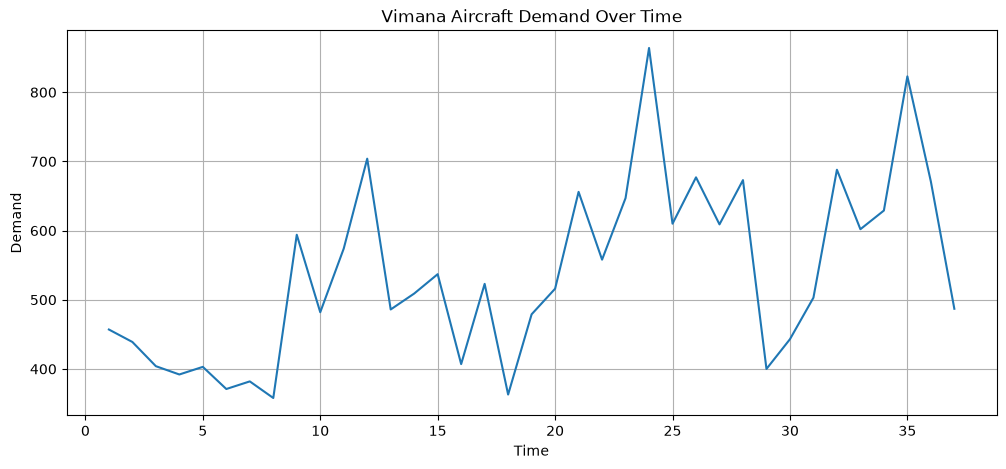

In [10]:
# Vimana Demand over Time

plt.figure(figsize=(12, 5))

plt.plot(vimana["Time"], vimana["demand"])

plt.title("Vimana Aircraft Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.grid(True)

plt.show()

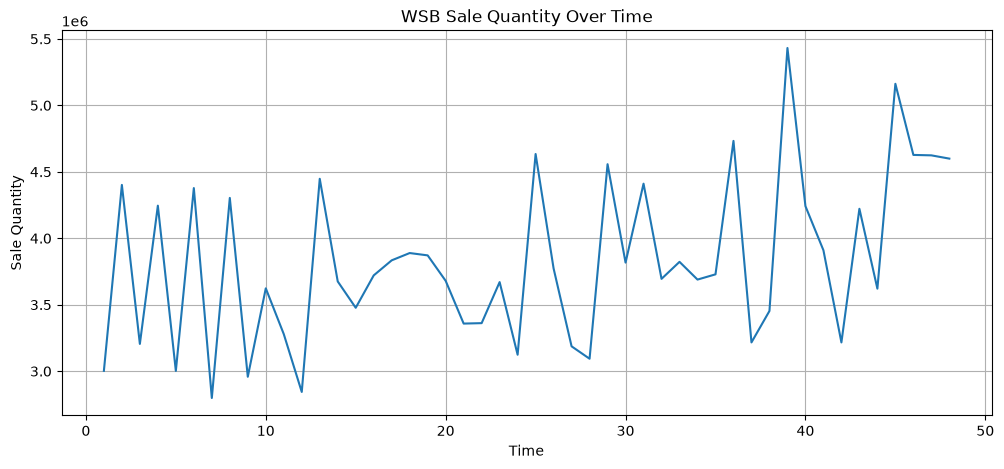

In [11]:
# WSB Sales Quantity over Time

plt.figure(figsize=(12, 5))

plt.plot(wsb["Time"], wsb["Sale Quantity"])

plt.title("WSB Sale Quantity Over Time")
plt.xlabel("Time")
plt.ylabel("Sale Quantity")
plt.grid(True)

plt.show()

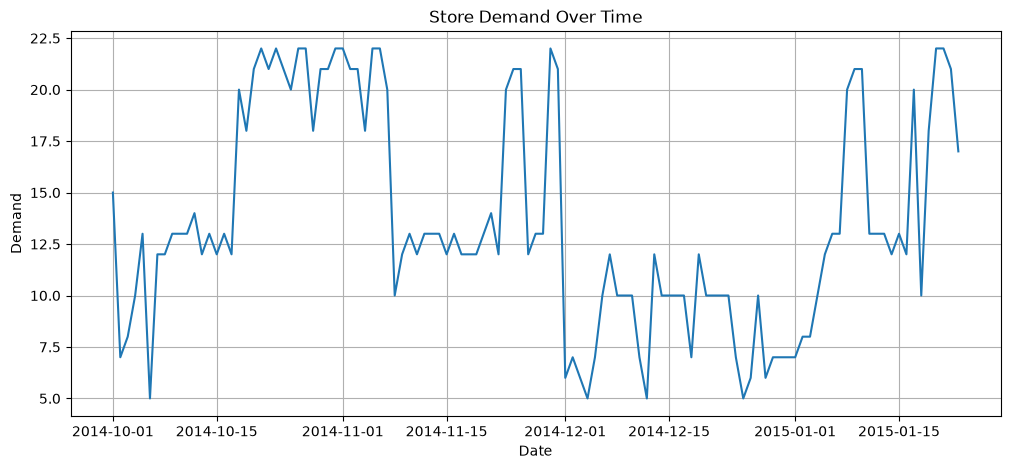

In [12]:
# Store Demand over Time

plt.figure(figsize=(12, 5))

plt.plot(store["Date"], store["demand"])

plt.title("Store Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(True)

plt.show()

In [13]:
# 3-Period Moving Average for Vimana Demand

vimana["Moving_Average_3"] = vimana["demand"].rolling(window=3).mean()

display(vimana.head(10))

,Month,demand,Time,Moving_Average_3
0,1970-01-01 00:00:00.000000001,457,1,NaN
1,1970-01-01 00:00:00.000000002,439,2,NaN
2,1970-01-01 00:00:00.000000003,404,3,433.333333
3,1970-01-01 00:00:00.000000004,392,4,411.666667
4,1970-01-01 00:00:00.000000005,403,5,399.666667
5,1970-01-01 00:00:00.000000006,371,6,388.666667
6,1970-01-01 00:00:00.000000007,382,7,385.333333
7,1970-01-01 00:00:00.000000008,358,8,370.333333
8,1970-01-01 00:00:00.000000009,594,9,444.666667
9,1970-01-01 00:00:00.000000010,482,10,478.000000


## 📉 Moving Average Forecasting

Moving Average is a simple forecasting technique that smooths short-term fluctuations by calculating the average of observations from a specified number of previous periods.

In this analysis, a **3-period Moving Average** was applied to the Vimana aircraft demand series.

### 🎯 Why Moving Average?

Moving Average helps:

- Reduce short-term fluctuations
- Smooth noisy time series data
- Identify the underlying movement of demand
- Provide a simple baseline for forecasting

The forecasting performance is evaluated using:

- **MAPE (Mean Absolute Percentage Error)** — measures average percentage forecasting error
- **RMSE (Root Mean Squared Error)** — measures the magnitude of forecasting errors, with greater emphasis on larger errors

### 💻 Implementation

A rolling window of 3 observations is used to calculate the moving average. The calculated average is shifted by one period so that the forecast uses previously observed values rather than the current demand.

### 📊 Result

The 3-period Moving Average achieved a **MAPE of 16.67%** and an **RMSE of 119.72** on the evaluated Vimana observations.

This provides a useful baseline against which more advanced forecasting techniques can be compared.

In [14]:
# Calculate 3-period moving average for Vimana demand

vimana["Moving_Average_3"] = (
    vimana["demand"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

display(vimana.head(10))

,Month,demand,Time,Moving_Average_3
0,1970-01-01 00:00:00.000000001,457,1,NaN
1,1970-01-01 00:00:00.000000002,439,2,NaN
2,1970-01-01 00:00:00.000000003,404,3,NaN
3,1970-01-01 00:00:00.000000004,392,4,433.333333
4,1970-01-01 00:00:00.000000005,403,5,411.666667
5,1970-01-01 00:00:00.000000006,371,6,399.666667
6,1970-01-01 00:00:00.000000007,382,7,388.666667
7,1970-01-01 00:00:00.000000008,358,8,385.333333
8,1970-01-01 00:00:00.000000009,594,9,370.333333
9,1970-01-01 00:00:00.000000010,482,10,444.666667


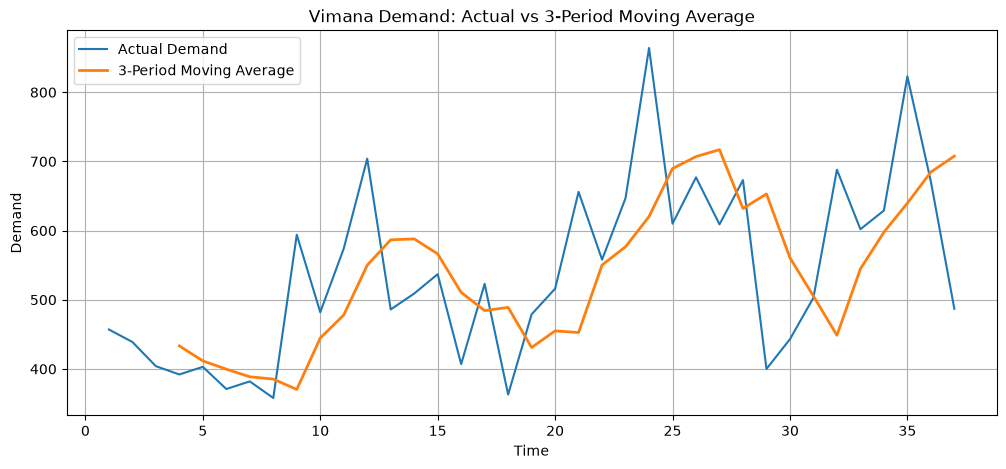

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    vimana["Time"],
    vimana["demand"],
    label="Actual Demand"
)

plt.plot(
    vimana["Time"],
    vimana["Moving_Average_3"],
    label="3-Period Moving Average",
    linewidth=2
)

plt.title("Vimana Demand: Actual vs 3-Period Moving Average")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Evaluate 3-period Moving Average forecast

ma_data = vimana.dropna(subset=["Moving_Average_3"]).copy()

mape_ma = mean_absolute_percentage_error(
    ma_data["demand"],
    ma_data["Moving_Average_3"]
)

rmse_ma = np.sqrt(
    mean_squared_error(
        ma_data["demand"],
        ma_data["Moving_Average_3"]
    )
)

print("Moving Average MAPE:", round(mape_ma * 100, 2), "%")
print("Moving Average RMSE:", round(rmse_ma, 2))

Moving Average MAPE: 16.67 %
Moving Average RMSE: 119.72


## ⚡ Exponential Smoothing

Exponential Smoothing is a forecasting technique that gives greater importance to recent observations while assigning progressively lower weights to older observations.

Unlike a simple Moving Average, where observations within the selected window receive equal weights, Exponential Smoothing allows recent demand values to have a stronger influence on the forecast.

### 🎯 Why Exponential Smoothing?

Exponential Smoothing is useful when:

- Recent observations are more relevant to future values
- The time series contains short-term fluctuations
- A smoother forecast is required
- We want a simple but more responsive forecasting method

### 💻 Implementation

An exponential weighted moving average is calculated using an **alpha value of 0.4**.

The alpha parameter controls how strongly recent observations influence the smoothed series.

- Higher alpha → greater weight to recent observations
- Lower alpha → smoother series with more influence from historical observations

### 📊 Result

The Exponential Smoothing approach achieved a **MAPE of 15.63%** on the evaluated Vimana observations.

This was the **lowest MAPE among the Vimana forecasting approaches evaluated in this project**, indicating that it produced the lowest average percentage forecasting error according to MAPE.

In [17]:
# Exponential Smoothing for Vimana Demand

vimana["Exponential_Smoothing"] = (
    vimana["demand"]
    .ewm(alpha=0.4, adjust=False)
    .mean()
    .shift(1)
)

display(vimana.head(10))

,Month,demand,Time,Moving_Average_3,Exponential_Smoothing
0,1970-01-01 00:00:00.000000001,457,1,NaN,NaN
1,1970-01-01 00:00:00.000000002,439,2,NaN,457.000000
2,1970-01-01 00:00:00.000000003,404,3,NaN,449.800000
3,1970-01-01 00:00:00.000000004,392,4,433.333333,431.480000
4,1970-01-01 00:00:00.000000005,403,5,411.666667,415.688000
5,1970-01-01 00:00:00.000000006,371,6,399.666667,410.612800
6,1970-01-01 00:00:00.000000007,382,7,388.666667,394.767680
7,1970-01-01 00:00:00.000000008,358,8,385.333333,389.660608
8,1970-01-01 00:00:00.000000009,594,9,370.333333,376.996365
9,1970-01-01 00:00:00.000000010,482,10,444.666667,463.797819


In [18]:
# Evaluate Exponential Smoothing forecast

es_data = vimana.dropna(subset=["Exponential_Smoothing"]).copy()

mape_es = mean_absolute_percentage_error(
    es_data["demand"],
    es_data["Exponential_Smoothing"]
)

rmse_es = np.sqrt(
    mean_squared_error(
        es_data["demand"],
        es_data["Exponential_Smoothing"]
    )
)

print("Exponential Smoothing MAPE:", round(mape_es * 100, 2), "%")
print("Exponential Smoothing RMSE:", round(rmse_es, 2))

Exponential Smoothing MAPE: 15.63 %
Exponential Smoothing RMSE: 115.55


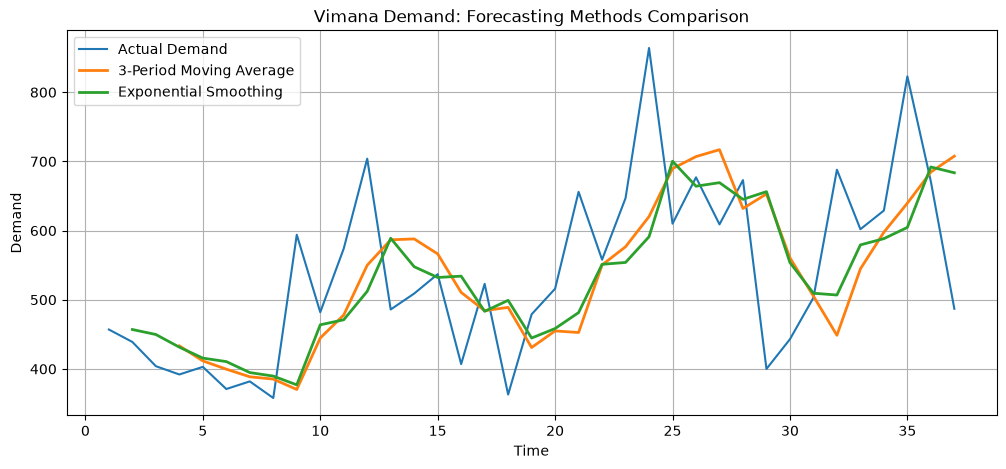

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    vimana["Time"],
    vimana["demand"],
    label="Actual Demand"
)

plt.plot(
    vimana["Time"],
    vimana["Moving_Average_3"],
    label="3-Period Moving Average",
    linewidth=2
)

plt.plot(
    vimana["Time"],
    vimana["Exponential_Smoothing"],
    label="Exponential Smoothing",
    linewidth=2
)

plt.title("Vimana Demand: Forecasting Methods Comparison")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Seasonal Decomposition of WSB Sale Quantity

wsb_decomposition = sm.tsa.seasonal_decompose(
    wsb["Sale Quantity"],
    model="multiplicative",
    period=12
)

wsb_decomposition.plot(figsize=(12, 10))

plt.suptitle(
    "Seasonal Decomposition of WSB Sale Quantity",
    y=1.02
)

plt.show()

TypeError: DecomposeResult.plot() got an unexpected keyword argument 'figsize'

## 🔄 Seasonal Decomposition

Seasonal Decomposition separates a time series into different components to help understand its underlying structure.

For the WSB sales series, a **multiplicative seasonal decomposition** with a period of **12 months** was used.

### 🧩 Components of Time Series

The decomposition separates the series into:

- **Observed** — the original sales series
- **Trend** — the long-term direction of sales
- **Seasonal** — repeating patterns across time
- **Residual** — the remaining unexplained variation

### 🎯 Why Seasonal Decomposition?

Seasonal decomposition helps identify whether changes in sales are associated with:

- 📈 Long-term trends
- 🔄 Repeating seasonal patterns
- 📊 Irregular fluctuations

A seasonal period of 12 is appropriate for monthly observations when examining potential yearly seasonality.

### 💻 Implementation

The WSB `Sale Quantity` series is decomposed using the multiplicative model with a period of 12 observations.

The resulting components are visualized to examine the trend, seasonal behavior, and residual variation.

### 💡 Interpretation

The decomposition provides a clearer view of the different patterns contributing to WSB sales. Separating these components helps determine whether observed changes are driven by long-term movement, recurring seasonal effects, or irregular variation.

In [ ]:
# Seasonal Decomposition of WSB Sale Quantity

wsb_decomposition = sm.tsa.seasonal_decompose(
    wsb["Sale Quantity"],
    model="multiplicative",
    period=12
)

fig = wsb_decomposition.plot()

fig.set_size_inches(12, 10)

plt.suptitle(
    "Seasonal Decomposition of WSB Sale Quantity",
    y=1.02
)

plt.show()

## 📐 Stationarity Analysis — Augmented Dickey-Fuller (ADF) Test

Stationarity is an important concept in time series analysis. A stationary time series has statistical properties such as its mean and variance that remain relatively stable over time.

Many statistical forecasting models perform better when the underlying time series is stationary. Therefore, the Augmented Dickey-Fuller (ADF) test was applied to the Vimana demand series.

### 🎯 ADF Test Hypotheses

- **H₀ (Null Hypothesis):** The time series is non-stationary.
- **H₁ (Alternative Hypothesis):** The time series is stationary.

A significance level of **5% (0.05)** is used.

### 📊 ADF Test Results

| Metric | Value |
|---|---:|
| ADF Statistic | **-1.6439** |
| p-value | **0.4602** |
| 5% Critical Value | **-2.9720** |

### 💡 Interpretation

The p-value of **0.4602** is greater than the 0.05 significance level.

Therefore, we **fail to reject the null hypothesis** and conclude that the Vimana demand series is **likely non-stationary**.

The ADF statistic of **-1.6439** is also less negative than the 5% critical value of **-2.9720**, providing further evidence that the series is not stationary.

Since the Vimana demand series is non-stationary, differencing can be considered as a transformation to help achieve stationarity before applying appropriate time series models.

In [ ]:
# Augmented Dickey-Fuller (ADF) Test for Vimana Demand

adf_result = adfuller(vimana["demand"])

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series is likely STATIONARY.")
else:
    print("\nConclusion: The series is likely NON-STATIONARY.")

In [ ]:
# Augmented Dickey-Fuller Test for Store Demand

adf_store = adfuller(store["demand"])

print("ADF Statistic:", round(adf_store[0], 4))
print("p-value:", round(adf_store[1], 4))

print("\nCritical Values:")
for key, value in adf_store[4].items():
    print(f"{key}: {value:.4f}")

if adf_store[1] < 0.05:
    print("\nConclusion: Store demand is likely STATIONARY.")
else:
    print("\nConclusion: Store demand is likely NON-STATIONARY.")

## 🔁 Differencing — Store Demand

Differencing is a time series transformation used to reduce non-stationarity by calculating the change between consecutive observations.

The first-order difference is calculated as:

**Differenced Demand = Current Demand − Previous Demand**

### 🎯 Why Differencing?

Differencing can help:

- Reduce trend-related effects
- Stabilize the time series
- Transform a non-stationary series into a more stationary form
- Prepare the data for models such as ARIMA

### 💻 Implementation

First-order differencing was applied to the Store demand series using the previous day's demand as the reference value.

The first observation produces a `NaN` value because there is no previous observation available for comparison.

### 💡 Interpretation

The resulting `Demand_diff` variable represents the day-to-day change in Store demand rather than the original demand level.

This transformed series can be used to examine changes in demand and supports the differencing component used in ARIMA modeling.

In [ ]:
# First-order differencing of Store Demand

store["Demand_diff"] = (
    store["demand"] - store["demand"].shift(1)
)

display(store.head(10))

In [ ]:
# ADF Test on Differenced Store Demand

store_diff = store["Demand_diff"].dropna()

adf_diff = adfuller(store_diff)

print("ADF Statistic:", round(adf_diff[0], 4))
print("p-value:", round(adf_diff[1], 4))

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

if adf_diff[1] < 0.05:
    print("\nConclusion: The differenced series is likely STATIONARY.")
else:
    print("\nConclusion: The differenced series is likely NON-STATIONARY.")

In [ ]:
# Plot Differenced Store Demand

plt.figure(figsize=(12, 5))

plt.plot(
    store["Date"],
    store["Demand_diff"]
)

plt.title("Differenced Store Demand")
plt.xlabel("Date")
plt.ylabel("Demand Difference")
plt.grid(True)

plt.show()

## 📈 Auto-Regressive (AR) Model

The Auto-Regressive (AR) model predicts the current value of a time series using its previous observations.

An AR model assumes that past values contain useful information about future values.

### 🎯 Why AR Modeling?

The AR approach is useful for:

- Understanding the relationship between current and previous observations
- Capturing short-term dependencies in a time series
- Modeling patterns where historical values influence future values
- Establishing a statistical forecasting baseline

### 💻 AR(1) Model

An **AR(1)** model uses one previous observation (one lag) to estimate the current value.

The model can be represented conceptually as:

**Current Value = Constant + Previous Value × Coefficient + Error**

### 📊 Model Evaluation

The AR(1) model was evaluated using MAPE and RMSE.

The model achieved:

- **MAPE: 17.09%**
- **RMSE: 111.03**

These metrics provide a quantitative measure of the model's forecasting error.

### 💡 Interpretation

The AR(1) model captures the relationship between consecutive demand observations. Its performance can be compared with Moving Average, Exponential Smoothing, MA, and ARMA approaches to understand which modeling approach better represents the Vimana demand series.

In [ ]:
# AR(1) Model for Vimana Demand

ar_model = AutoReg(
    vimana["demand"],
    lags=1,
    trend="c"
).fit()

print(ar_model.summary())

In [ ]:
# Generate AR(1) predictions

ar_predictions = ar_model.predict(
    start=1,
    end=len(vimana) - 1,
    dynamic=False
)

ar_actual = vimana["demand"].iloc[1:]

# Evaluate AR(1)

mape_ar = mean_absolute_percentage_error(
    ar_actual,
    ar_predictions
)

rmse_ar = np.sqrt(
    mean_squared_error(
        ar_actual,
        ar_predictions
    )
)

print("AR(1) MAPE:", round(mape_ar * 100, 2), "%")
print("AR(1) RMSE:", round(rmse_ar, 2))

In [ ]:
# Plot AR(1) predictions vs actual demand

plt.figure(figsize=(12, 5))

plt.plot(
    vimana["Time"].iloc[1:],
    ar_actual,
    label="Actual Demand"
)

plt.plot(
    vimana["Time"].iloc[1:],
    ar_predictions,
    label="AR(1) Prediction",
    linewidth=2
)

plt.title("Vimana Demand: AR(1) Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

## 📉 Moving Average (MA) Model

The Moving Average (MA) model is a statistical time series model that uses previous forecast errors to model the current value of a time series.

Unlike the simple Moving Average forecasting method used earlier, the **MA model is based on past error terms**.

### 🎯 Why MA Modeling?

The MA approach helps:

- Model the relationship between current observations and past errors
- Capture short-term shock or disturbance patterns
- Understand how previous forecasting errors influence future observations
- Provide another statistical baseline for time series modeling

### 💻 MA(1) Model

An **MA(1)** model uses the previous period's error term to help estimate the current observation.

The model can be represented conceptually as:

**Current Value = Constant + Current Error + Previous Error × Coefficient**

### 📊 Model Evaluation

The MA(1) model was evaluated using MAPE and RMSE.

The model achieved:

- **MAPE: 18.25%**
- **RMSE: 116.18**

### 💡 Interpretation

The MA(1) model captures short-term effects of previous forecasting errors in the Vimana demand series.

Its performance can be compared with AR(1), ARMA(1,1), Moving Average forecasting, and Exponential Smoothing to determine which approach provides better forecasting accuracy.

In [ ]:
# MA(1) Model for Vimana Demand

ma_model = sm.tsa.ARIMA(
    vimana["demand"],
    order=(0, 0, 1)
).fit()

print(ma_model.summary())

In [ ]:
# Generate MA(1) predictions

ma_predictions = ma_model.predict(
    start=1,
    end=len(vimana) - 1,
    dynamic=False
)

ma_actual = vimana["demand"].iloc[1:]

# Evaluate MA(1)

mape_ma_model = mean_absolute_percentage_error(
    ma_actual,
    ma_predictions
)

rmse_ma_model = np.sqrt(
    mean_squared_error(
        ma_actual,
        ma_predictions
    )
)

print("MA(1) MAPE:", round(mape_ma_model * 100, 2), "%")
print("MA(1) RMSE:", round(rmse_ma_model, 2))

In [ ]:
# Plot MA(1) predictions vs actual demand

plt.figure(figsize=(12, 5))

plt.plot(
    vimana["Time"].iloc[1:],
    ma_actual,
    label="Actual Demand"
)

plt.plot(
    vimana["Time"].iloc[1:],
    ma_predictions,
    label="MA(1) Prediction",
    linewidth=2
)

plt.title("Vimana Demand: MA(1) Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

## 🔀 ARMA (Auto-Regressive Moving Average) Model

ARMA combines two statistical components:

- **AR (Auto-Regressive)** — uses previous values of the time series
- **MA (Moving Average)** — uses previous forecast errors

Combining these components allows the model to capture both historical dependencies and the effect of previous errors.

### 🎯 Purpose

The ARMA model was applied to examine whether combining autoregressive and moving-average components could improve forecasting performance for the Vimana demand series.

### 💻 ARMA(1,1)

An **ARMA(1,1)** model was implemented using:

- **AR order (p) = 1**
- **Differencing (d) = 0**
- **MA order (q) = 1**

The model therefore uses one lag of the series and one previous error term without applying differencing.

### 📊 Model Evaluation

The ARMA(1,1) model achieved:

- **MAPE: 16.44%**
- **RMSE: 109.51**

The model achieved the **lowest RMSE among the evaluated Vimana models**, while Exponential Smoothing achieved the lowest MAPE.

### 💡 Interpretation

The ARMA(1,1) model captures both the dependency between consecutive observations and the influence of previous forecasting errors.

Its lower RMSE indicates that it produced the lowest magnitude of squared forecasting error among the evaluated Vimana models.

In [ ]:
# ARMA(1,1) Model for Vimana Demand

arma_model = ARIMA(
    vimana["demand"],
    order=(1, 0, 1)
).fit()

print(arma_model.summary())

In [ ]:
# Generate ARMA(1,1) predictions

arma_predictions = arma_model.predict(
    start=1,
    end=len(vimana) - 1,
    dynamic=False
)

arma_actual = vimana["demand"].iloc[1:]

# Evaluate ARMA(1,1)

mape_arma = mean_absolute_percentage_error(
    arma_actual,
    arma_predictions
)

rmse_arma = np.sqrt(
    mean_squared_error(
        arma_actual,
        arma_predictions
    )
)

print("ARMA(1,1) MAPE:", round(mape_arma * 100, 2), "%")
print("ARMA(1,1) RMSE:", round(rmse_arma, 2))

In [ ]:
# Plot ARMA(1,1) predictions vs actual demand

plt.figure(figsize=(12, 5))

plt.plot(
    vimana["Time"].iloc[1:],
    arma_actual,
    label="Actual Demand"
)

plt.plot(
    vimana["Time"].iloc[1:],
    arma_predictions,
    label="ARMA(1,1) Prediction",
    linewidth=2
)

plt.title("Vimana Demand: ARMA(1,1) Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Train-Test Split for ARIMA

store_train = store.iloc[:100].copy()
store_test = store.iloc[100:].copy()

print("Training observations:", len(store_train))
print("Testing observations:", len(store_test))

print("\nTraining period:")
print(store_train["Date"].min(), "to", store_train["Date"].max())

print("\nTesting period:")
print(store_test["Date"].min(), "to", store_test["Date"].max())

## 📈 ARIMA Forecasting

ARIMA (Auto-Regressive Integrated Moving Average) is a time series forecasting model that combines three components:

- **AR (Auto-Regressive)** — uses previous observations
- **I (Integrated)** — uses differencing to reduce non-stationarity
- **MA (Moving Average)** — uses previous forecast errors

### 🎯 Purpose

ARIMA was applied to the **Store demand dataset** to perform an out-of-sample forecasting exercise.

The Store dataset contains **115 daily observations**. The data was divided chronologically into:

- **100 observations for training**
- **15 observations for testing**

This chronological split ensures that future observations are not used to train the model.

### 💻 ARIMA(1,1,1)

An **ARIMA(1,1,1)** model was implemented with:

- **p = 1** → one autoregressive term
- **d = 1** → first-order differencing
- **q = 1** → one moving-average term

The model was trained using the first 100 Store demand observations and used to forecast the following 15 observations.

### 📊 Forecasting Evaluation

The forecasts were compared with the actual demand values in the test period.

Model performance was evaluated using:

- **MAPE (Mean Absolute Percentage Error)**
- **RMSE (Root Mean Squared Error)**

The resulting metrics provide an objective assessment of the ARIMA model's out-of-sample forecasting performance.

### 💡 Interpretation

The ARIMA model demonstrates how historical demand patterns, differencing, and previous forecast errors can be combined to generate forecasts for future observations.

The actual-versus-forecast comparison provides a visual assessment of how closely the model follows the observed Store demand during the test period.

In [ ]:
# Build ARIMA(1,1,1) model

arima_model = ARIMA(
    store_train["demand"].astype(np.float64),
    order=(1, 1, 1)
).fit()

print(arima_model.summary())

In [ ]:
# Generate ARIMA forecast for the test period

arima_forecast = arima_model.forecast(
    steps=len(store_test)
)

print("Number of forecasts:", len(arima_forecast))
display(arima_forecast)

## 📊 Model Evaluation and Comparison

To evaluate forecasting performance, the models were assessed using two commonly used error metrics:

- **MAPE (Mean Absolute Percentage Error):** Measures the average forecasting error as a percentage. Lower values indicate better percentage accuracy.
- **RMSE (Root Mean Squared Error):** Measures the magnitude of forecasting errors and gives greater weight to larger errors. Lower values indicate better performance.

### ✈️ Vimana Dataset — Model Comparison

The following forecasting approaches were evaluated on the Vimana demand series:

- 3-Period Moving Average
- Exponential Smoothing
- AR(1)
- MA(1)
- ARMA(1,1)

### 📌 Comparison Results

The results are presented in the table below.

The model with the lowest **MAPE** provides the best performance according to percentage-based forecasting accuracy, while the model with the lowest **RMSE** produces the lowest overall magnitude of squared forecasting error.

### 💡 Interpretation

Based on the evaluation:

- **Exponential Smoothing** achieved the lowest MAPE of **15.63%**.
- **ARMA(1,1)** achieved the lowest RMSE of **109.51**.

Therefore, there is no single model that is best according to both evaluation metrics. Model selection depends on the business objective and the error metric considered most important.

### 🏪 Store Dataset — ARIMA Evaluation

The **ARIMA(1,1,1)** model was evaluated separately on the Store dataset.

The model was trained using the first **100 observations** and tested on the remaining **15 observations**.

Its MAPE and RMSE are reported separately below because the ARIMA model was evaluated on a different dataset and test period from the Vimana models.

In [ ]:
# Compare Actual Store Demand vs ARIMA Forecast

plt.figure(figsize=(12, 5))

plt.plot(
    store_train["Date"],
    store_train["demand"],
    label="Training Demand"
)

plt.plot(
    store_test["Date"],
    store_test["demand"],
    label="Actual Test Demand",
    linewidth=2
)

plt.plot(
    store_test["Date"],
    arima_forecast,
    label="ARIMA Forecast",
    linewidth=2
)

plt.title("Store Demand: Actual vs ARIMA(1,1,1) Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Final ARIMA Model Evaluation

mape_arima = mean_absolute_percentage_error(
    store_test["demand"],
    arima_forecast
)

rmse_arima = np.sqrt(
    mean_squared_error(
        store_test["demand"],
        arima_forecast
    )
)

print("ARIMA(1,1,1) MAPE:", round(mape_arima * 100, 2), "%")
print("ARIMA(1,1,1) RMSE:", round(rmse_arima, 2))

## 🔍 Residual Analysis

Residuals represent the difference between the observed values and the values estimated by the forecasting model.

Analyzing residuals helps assess whether the ARIMA model has captured the main patterns in the Store demand series.

### 🎯 Purpose of Residual Analysis

Residual analysis helps to:

- Identify unexplained patterns in the model
- Detect unusually large forecasting errors
- Examine whether errors fluctuate around zero
- Assess the remaining variation after model fitting

### 📊 Residual Visualization

The residuals from the **ARIMA(1,1,1)** model are plotted over the observations.

Ideally, residuals should fluctuate around zero without a clear systematic pattern. A visible trend or repeated structure may indicate that additional information remains unexplained by the model.

### 💡 Interpretation

The residual plot provides a diagnostic view of the ARIMA model and helps evaluate whether substantial structure remains in the model errors.

In [ ]:
# ARIMA Residual Analysis

arima_residuals = arima_model.resid

plt.figure(figsize=(12, 5))

plt.plot(arima_residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("ARIMA(1,1,1) Residuals")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

In [ ]:
# Correct evaluation summary

print("VIMANA DATASET — Model Comparison")
print("=" * 45)

vimana_comparison = pd.DataFrame({
    "Model": [
        "3-Period Moving Average",
        "Exponential Smoothing",
        "AR(1)",
        "MA(1)",
        "ARMA(1,1)"
    ],
    "MAPE (%)": [
        mape_ma * 100,
        mape_es * 100,
        mape_ar * 100,
        mape_ma_model * 100,
        mape_arma * 100
    ],
    "RMSE": [
        rmse_ma,
        rmse_es,
        rmse_ar,
        rmse_ma_model,
        rmse_arma
    ]
})

vimana_comparison["MAPE (%)"] = vimana_comparison["MAPE (%)"].round(2)
vimana_comparison["RMSE"] = vimana_comparison["RMSE"].round(2)

display(vimana_comparison.sort_values("MAPE (%)"))

print("\nSTORE DATASET — ARIMA Evaluation")
print("=" * 45)

print("ARIMA(1,1,1) MAPE:", round(mape_arima * 100, 2), "%")
print("ARIMA(1,1,1) RMSE:", round(rmse_arima, 2))

# Final Conclusion

## Project Summary

This project explored different time series analysis and forecasting techniques using Vimana aircraft demand, WSB sales, and Store demand datasets.

The analysis covered:

- Time series data exploration and visualization
- Moving Average forecasting
- Exponential Smoothing
- Seasonal Decomposition
- Augmented Dickey-Fuller (ADF) stationarity testing
- First-order differencing
- Auto-Regressive (AR) modeling
- Moving Average (MA) modeling
- ARMA modeling
- ARIMA forecasting
- Residual analysis
- Forecast evaluation using MAPE and RMSE

## Key Findings

Moving Average provided a simple baseline forecasting approach by smoothing recent observations.

Exponential Smoothing assigned greater importance to recent observations and provided an alternative forecasting approach.

Seasonal Decomposition was used to separate WSB sales into observed, trend, seasonal, and residual components, helping identify underlying patterns in the series.

The Augmented Dickey-Fuller test was used to assess stationarity. First-order differencing was applied to the Store demand series to transform the series before ARIMA modeling.

AR, MA, and ARMA models were explored to understand different components of time-series behavior.

Finally, an ARIMA(1,1,1) model was trained using the first 100 Store demand observations and evaluated on the remaining 15 observations.

## ⚠️ Limitations

Although the project demonstrates several time series analysis and forecasting techniques, there are some limitations to consider:

- The datasets contain relatively limited numbers of observations, which may restrict the generalizability of the forecasting results.
- Different forecasting models were evaluated on different datasets, so their performance metrics should not be interpreted as a direct cross-dataset comparison.
- The AR, MA, and ARMA models were explored using fixed model orders rather than an extensive automated model-selection procedure.
- The ARIMA analysis used a fixed `(1,1,1)` configuration and a chronological train-test split.
- External factors that may influence demand or sales were not incorporated into the final forecasting models.
- Forecast accuracy may change when the models are applied to larger or more recent datasets.

These limitations highlight areas where the analysis could be extended for more robust real-world forecasting applications.

## 🚀 Future Improvements

The analysis can be extended further to improve forecasting accuracy and practical applicability.

- Test additional ARIMA and SARIMA parameter combinations using systematic model selection.
- Explore automated parameter tuning based on forecasting performance.
- Incorporate external variables such as promotions, competition, and other demand-related factors where available.
- Evaluate additional forecasting techniques such as Holt-Winters and other advanced time series models.
- Use larger and more recent datasets to improve model robustness.
- Perform additional residual diagnostics to further validate model assumptions.
- Evaluate forecasting performance using rolling or walk-forward validation for a more robust assessment.

These improvements could help develop more reliable forecasting solutions for real-world demand and sales planning.

## Model Evaluation

The forecasting models were compared using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

A lower MAPE and RMSE indicate lower forecasting error. The model comparison table provides the quantitative basis for identifying the better-performing forecasting approach.

## Business Insights

Time series forecasting can help businesses:

- Estimate future demand
- Improve inventory planning
- Support production and capacity planning
- Identify seasonal patterns
- Reduce the risk of overstocking or stockouts
- Improve operational decision-making

## Conclusion

The project demonstrates an end-to-end time series forecasting workflow, beginning with data exploration and visualization, followed by stationarity analysis, transformation, model development, forecasting, evaluation, and residual analysis.

The analysis shows that selecting an appropriate forecasting technique depends on the characteristics of the time series, including trend, seasonality, stationarity, and historical patterns.

# Skills Demonstrated

## Technical Skills

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- Time Series Analysis
- Forecasting
- Statistical Modeling
- AR, MA and ARMA Models
- ARIMA Modeling
- Stationarity Analysis
- Augmented Dickey-Fuller (ADF) Test
- Differencing
- Seasonal Decomposition
- Model Evaluation
- MAPE and RMSE

## Data Science Workflow

1. Data loading and validation
2. Data exploration
3. Statistical summary
4. Time-series visualization
5. Moving Average forecasting
6. Exponential Smoothing
7. Seasonal Decomposition
8. Stationarity testing
9. Differencing
10. AR / MA / ARMA modeling
11. ARIMA forecasting
12. Model evaluation
13. Residual analysis
14. Business interpretation